### Worksheet Summary: Understanding Linear Regression and R-squared

This worksheet demonstrates the concept of Linear Regression and the importance of the R-squared metric through two distinct examples.

#### Key Concepts Covered:
1.  **Linear Regression:** A statistical model used to predict a continuous outcome variable (dependent variable) based on one or more predictor variables (independent variables).
2.  **Train-Test Split:** A crucial step in machine learning where the dataset is divided into a training set (to train the model) and a testing set (to evaluate the model's performance on unseen data). This ensures an unbiased evaluation of the model's generalization capabilities.
3.  **R-squared (Coefficient of Determination):** A statistical measure that represents the proportion of the variance in the dependent variable that can be explained by the independent variables in a linear regression model.
    *   **Value Range:** R-squared typically ranges from 0 to 1.
    *   **Positive R-squared:** Indicates that the model explains a certain percentage of the variance in the target variable, with higher values meaning a better fit.
    *   **Negative R-squared:** Occurs when the model performs worse than simply predicting the mean of the dependent variable. This usually means there is no linear relationship, or the model is poorly fitted.

#### Example 1: Demonstrating Negative R-squared
*   **Data Generation:** Random data (`X` and `y`) was generated with no inherent linear relationship between them.
*   **Model Training & Evaluation:** A Linear Regression model was trained on this data.
*   **Result:** The R-squared value was **negative (-0.6208)**, indicating a very poor fit. The model was unable to find a meaningful linear relationship because none existed in the randomly generated data.
*   **Visualization:** The scatter plot for this example clearly shows the scattered data points and a regression line that does not effectively capture any trend, visually confirming the negative R-squared.

#### Example 2: Demonstrating Positive R-squared
*   **Data Generation:** New data (`X_new` and `y_new`) was generated with a clear, predefined linear relationship (`y = 4 + 3 * X + noise`).
*   **Model Training & Evaluation:** A new Linear Regression model was trained on this data.
*   **Result:** The R-squared value was **positive (0.6521)**, indicating a good fit. The model successfully identified the underlying linear relationship.
*   **Model Parameters:** The model's coefficients (`2.9903`) and intercept (`4.2063`) were very close to the true values used to generate the data, further confirming a successful fit.
*   **Visualization:** The scatter plot for this example shows data points clustered around the regression line, which accurately represents the linear trend, visually confirming the positive R-squared and the model's effectiveness.

### Visualization of the First Linear Regression Model

Let's visualize the first dataset and the regression line fitted by our model. This will help us understand why the R-squared was negative.

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Generate some dummy data for demonstration purposes
# We'll create 100 samples (rows) with 5 features (columns) for our independent variable X.
# The dependent variable y will also have 100 samples.
# np.random.seed(42) ensures that the random data generated is consistent across runs.
np.random.seed(42)
X = np.random.rand(100, 5) # Features (independent variables)
y = np.random.rand(100)   # Target (dependent variable)

# 2. Split the data into training and testing sets
# train_test_split is crucial for evaluating model performance on unseen data.
# test_size=0.2 means 20% of the data will be used for testing, and 80% for training.
# random_state=42 ensures the data split is reproducible, meaning X_train, X_test, etc.,
# will always contain the same data points every time the code is run with this seed.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the original and split datasets to verify the split
print(f"Original X shape: {X.shape}")
print(f"Training X shape: {X_train.shape}") # Expected: 80 samples, 5 features
print(f"Testing X shape:  {X_test.shape}\n")   # Expected: 20 samples, 5 features

# 3. Train the Linear Regression model
# We initialize a Linear Regression model.
# The model is trained ONLY on the training data (X_train, y_train) to learn the relationships.
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluate the model's performance on the testing set
# After training, the model's performance is assessed ONLY on the unseen testing data (X_test, y_test).
# This provides an unbiased estimate of how well the model generalizes to new, real-world data.
# The .score() method for LinearRegression returns the R-squared (coefficient of determination).
# R-squared measures the proportion of variance in the dependent variable that can be predicted
# from the independent variables. A higher R-squared generally indicates a better fit, though
# a negative value indicates a very poor fit (worse than simply predicting the mean).
test_accuracy = model.score(X_test, y_test)
print(f"Unbiased Test R-squared: {test_accuracy:.4f}")

Original X shape: (100, 5)
Training X shape: (80, 5)
Testing X shape:  (20, 5)

Unbiased Test R-squared: -0.6208


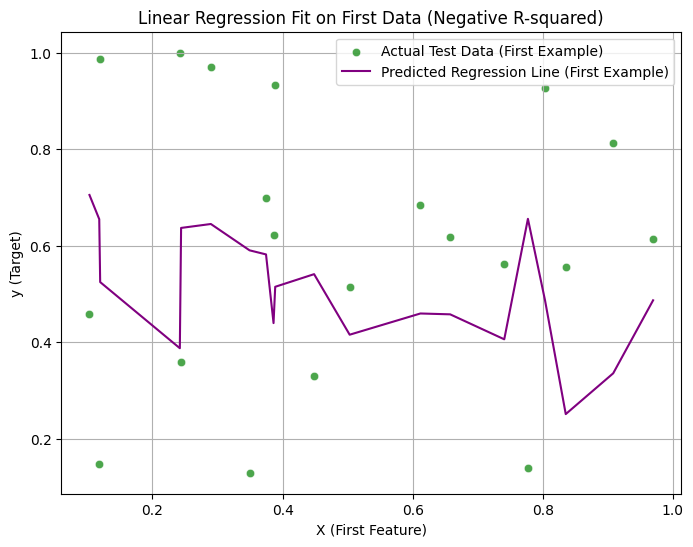

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predict y values using the trained model on the test set from the first example
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
# Scatter plot of the first example's test data (using the first feature for visualization)
sns.scatterplot(x=X_test[:, 0], y=y_test, label='Actual Test Data (First Example)', color='green', alpha=0.7)
# Plot the regression line (using the first feature for visualization, showing the predicted trend)
sns.lineplot(x=X_test[:, 0], y=y_pred, label='Predicted Regression Line (First Example)', color='purple')

plt.title('Linear Regression Fit on First Data (Negative R-squared)')
plt.xlabel('X (First Feature)')
plt.ylabel('y (Target)')
plt.legend()
plt.grid(True)
plt.show()

### Second Example: Demonstrating a Positive R-squared

Let's create a new dataset where `y` has a clear linear dependency on `X` plus some random noise. This should result in a positive R-squared value, indicating a better fit.

In [3]:
# 1. Generate new dummy data with a clear linear relationship
np.random.seed(0) # Use a different seed for this example
X_new = 2 * np.random.rand(100, 1) # A single feature for easier visualization
y_new = 4 + 3 * X_new + np.random.randn(100, 1) # y = 4 + 3*X + noise

# 2. Split the new data into training and testing sets
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

print(f"Original X_new shape: {X_new.shape}")
print(f"Training X_new shape: {X_new_train.shape}")
print(f"Testing X_new shape:  {X_new_test.shape}\n")

Original X_new shape: (100, 1)
Training X_new shape: (80, 1)
Testing X_new shape:  (20, 1)



In [4]:
# 3. Train a new Linear Regression model on the new training data
model_new = LinearRegression()
model_new.fit(X_new_train, y_new_train)

# 4. Evaluate the new model's performance on the testing set
new_test_accuracy = model_new.score(X_new_test, y_new_test)
print(f"New Unbiased Test R-squared: {new_test_accuracy:.4f}")

# 5. Display the model's coefficients and intercept
print(f"\nModel Coefficients: {model_new.coef_[0][0]:.4f}") # For a single feature
print(f"Model Intercept: {model_new.intercept_[0]:.4f}")

New Unbiased Test R-squared: 0.6521

Model Coefficients: 2.9903
Model Intercept: 4.2063


### Visualization of the New Linear Regression Model

Let's visualize the new dataset and the regression line fitted by our model to see the linear relationship.

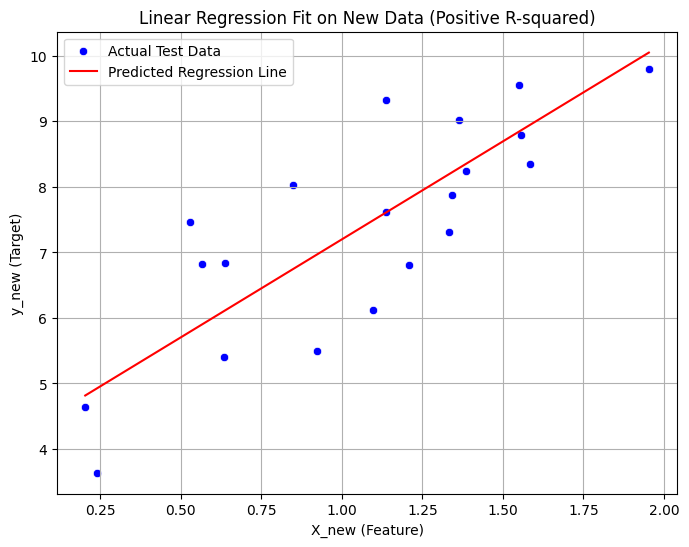

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predict y values using the trained model on the test set
y_new_pred = model_new.predict(X_new_test)

plt.figure(figsize=(8, 6))
# Scatter plot of the test data
sns.scatterplot(x=X_new_test.flatten(), y=y_new_test.flatten(), label='Actual Test Data', color='blue')
# Plot the regression line
sns.lineplot(x=X_new_test.flatten(), y=y_new_pred.flatten(), label='Predicted Regression Line', color='red')

plt.title('Linear Regression Fit on New Data (Positive R-squared)')
plt.xlabel('X_new (Feature)')
plt.ylabel('y_new (Target)')
plt.legend()
plt.grid(True)
plt.show()